In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
df = pd.read_csv("car data.csv")

print(df.head())

  Car_Name  Year  Selling_Price  Present_Price  Driven_kms Fuel_Type  \
0     ritz  2014           3.35           5.59       27000    Petrol   
1      sx4  2013           4.75           9.54       43000    Diesel   
2     ciaz  2017           7.25           9.85        6900    Petrol   
3  wagon r  2011           2.85           4.15        5200    Petrol   
4    swift  2014           4.60           6.87       42450    Diesel   

  Selling_type Transmission  Owner  
0       Dealer       Manual      0  
1       Dealer       Manual      0  
2       Dealer       Manual      0  
3       Dealer       Manual      0  
4       Dealer       Manual      0  


In [4]:
print("Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

print("\nStatistics:")
print(df.describe())

Shape: (301, 9)

Columns:
['Car_Name', 'Year', 'Selling_Price', 'Present_Price', 'Driven_kms', 'Fuel_Type', 'Selling_type', 'Transmission', 'Owner']

Missing Values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64

Data Types:
Car_Name          object
Year               int64
Selling_Price    float64
Present_Price    float64
Driven_kms         int64
Fuel_Type         object
Selling_type      object
Transmission      object
Owner              int64
dtype: object

Statistics:
              Year  Selling_Price  Present_Price     Driven_kms       Owner
count   301.000000     301.000000     301.000000     301.000000  301.000000
mean   2013.627907       4.661296       7.628472   36947.205980    0.043189
std       2.891554       5.082812       8.642584   38886.883882    0.247915
min    2003.000000       0.100000       0.320000     500.000000    0.000000
25%  

In [5]:
# Checking duplicates
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 2


In [6]:
# Removing duplicates
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [8]:
# columns
print(df.select_dtypes(include="object").columns.tolist())

['Car_Name', 'Fuel_Type', 'Selling_type', 'Transmission']


In [9]:
# Converting columns
df = pd.get_dummies(df, drop_first=True)

print(df.head())

   Year  Selling_Price  Present_Price  Driven_kms  Owner  Car_Name_Activa 3g  \
0  2014           3.35           5.59       27000      0               False   
1  2013           4.75           9.54       43000      0               False   
2  2017           7.25           9.85        6900      0               False   
3  2011           2.85           4.15        5200      0               False   
4  2014           4.60           6.87       42450      0               False   

   Car_Name_Activa 4g  Car_Name_Bajaj  ct 100  Car_Name_Bajaj Avenger 150  \
0               False                   False                       False   
1               False                   False                       False   
2               False                   False                       False   
3               False                   False                       False   
4               False                   False                       False   

   Car_Name_Bajaj Avenger 150 street  ...  Car_Name_swif

In [10]:
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

In [11]:
# Separating the features and target
X = df.drop("Selling_Price", axis=1)
y = df["Selling_Price"]

print("Features:", X.shape)
print("Target:", y.shape)

Features: (299, 105)
Target: (299,)


In [12]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 105)
Testing data: (60, 105)


In [13]:
# training model
model = LinearRegression()

model.fit(X_train, y_train)

print("Model training completed!")

Model training completed!


In [14]:
# Predictions
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[ 8.88188372  8.17760013  1.01356874  6.64719403 10.23372694  4.83254978
  8.14099351  2.608042   15.5590327   4.49265367]


In [15]:
# Evaluating model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Mean Absolute Error: 2.6226290845462534
Root Mean Squared Error: 4.128261467951703
R² Score: 0.3387510435880976


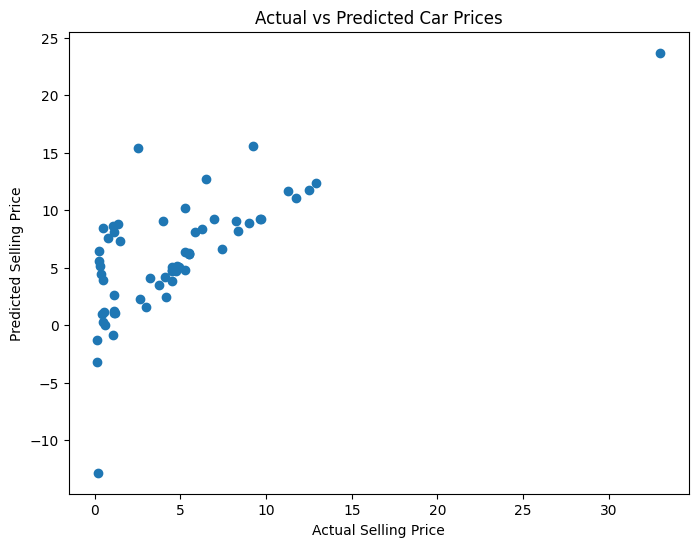

In [16]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

plt.xlabel("Actual Selling Price")
plt.ylabel("Predicted Selling Price")
plt.title("Actual vs Predicted Car Prices")

plt.show()

In [17]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

feature_importance = feature_importance.sort_values(
    by="Coefficient",
    ascending=False
)

print(feature_importance.head(10))

                     Feature   Coefficient
101         Fuel_Type_Diesel  1.626030e+00
102         Fuel_Type_Petrol  7.184862e-01
1              Present_Price  5.917724e-01
0                       Year  5.088135e-01
3                      Owner  1.117335e-01
103  Selling_type_Individual  9.455413e-02
94          Car_Name_s cross  3.798173e-11
57       Car_Name_TVS Sport   2.091083e-11
61     Car_Name_Yamaha FZ 16  1.889594e-11
24     Car_Name_Hero Glamour  8.380852e-12


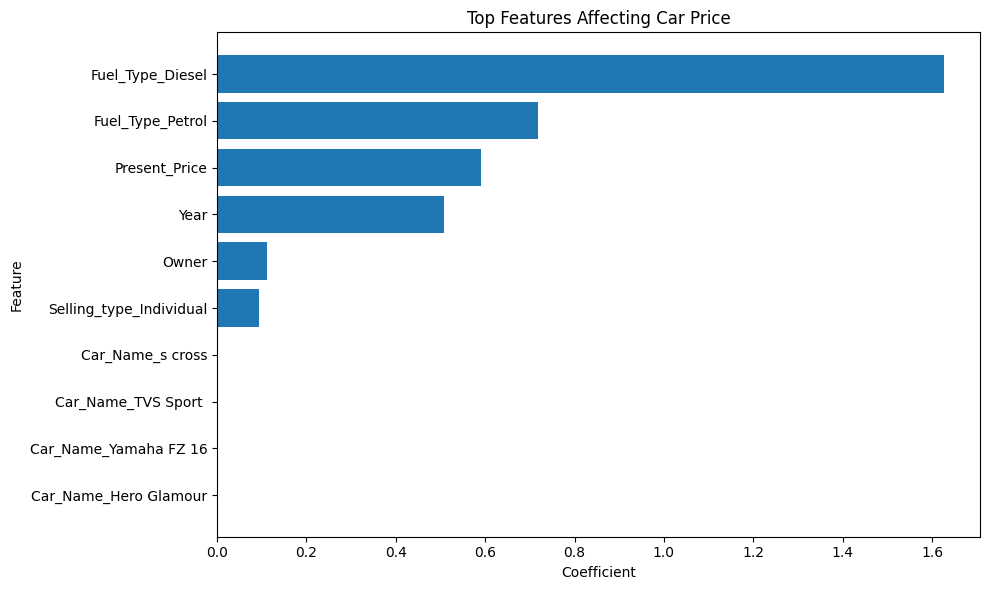

In [21]:
# Visualizing imp. coefficient
top_features = feature_importance.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"],
    top_features["Coefficient"]
)

plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.title("Top Features Affecting Car Price")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [20]:
  # Testing
sample = X_test.iloc[[0]]

predicted_price = model.predict(sample)[0]
actual_price = y_test.iloc[0]

print("Predicted Selling Price:", predicted_price)
print("Actual Selling Price:", actual_price)

Predicted Selling Price: 8.881883721146892
Actual Selling Price: 8.99


# **Conclusion**:
 A Linear Regression model was developed to predict car selling prices using vehicle features. The model was evaluated using MAE, RMSE, and R², providing useful insights into its prediction performance